In [1]:
import torch
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
# Define the same network structure used in training
class DigitClassifier(torch.nn.Module):
    def __init__(self):
        super(DigitClassifier, self).__init__()
        self.network = torch.nn.Sequential(
            torch.nn.Linear(784, 1024),
            torch.nn.LeakyReLU(0.1),
            torch.nn.Linear(1024, 1024),
            torch.nn.LeakyReLU(0.1),
            torch.nn.Linear(1024, 10)
        )
    
    def forward(self, x):
        return self.network(x)

In [9]:
def load_mnist_split(split='test'):
    """Load numpy files from train/valid/test splits"""
    proj_root = Path.cwd().parent.parent
    data_dir = proj_root / 'data'
    images_dir = data_dir / split / 'images'
    labels_dir = data_dir / split / 'labels'
    
    images = []
    labels = []
    
    # Get all image files
    img_files = sorted(images_dir.glob('*.npy'))
    
    for img_file in img_files:
        img = np.load(img_file).astype(np.float32)
        label = np.load(labels_dir / img_file.name)
        images.append(img)
        labels.append(label)
    
    # Stack into arrays
    images = np.array(images)
    labels = np.array(labels)
    
    # Normalize images to [0, 1] and flatten
    images = images.reshape(len(images), -1) / 255.0
    
    return images, labels

In [10]:
# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load model
model = DigitClassifier().to(device)
model.load_state_dict(torch.load('/home/turu/Documents/FUTURE/Hand-Drawn-Doodle-Classsifier/models/mnist_classifier.pth', map_location=device))
model.eval()
print("Model loaded successfully!")

# Load test data
print("Loading test data...")
test_images, test_labels = load_mnist_split('test')
test_tensor = torch.FloatTensor(test_images).to(device)
test_labels_tensor = torch.LongTensor(test_labels).to(device)
print(f"Test data loaded: {test_images.shape}")


Using device: cuda
Model loaded successfully!
Loading test data...
Test data loaded: (10000, 784)


In [11]:
# Evaluate
correct = 0
with torch.no_grad():
    outputs = model(test_tensor)
    _, predicted = torch.max(outputs, 1)
    correct = (predicted == test_labels_tensor).sum().item()

accuracy = 100 * correct / len(test_labels)
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 98.05%


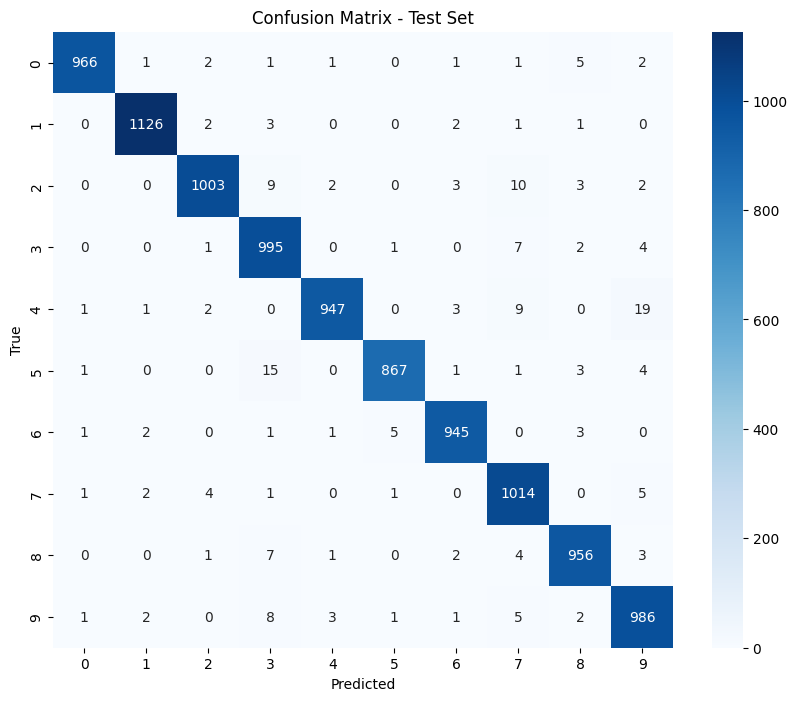

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get all predictions
with torch.no_grad():
    all_outputs = model(test_tensor)
    _, all_predicted = torch.max(all_outputs, 1)
    
# Convert to numpy
y_true = test_labels
y_pred = all_predicted.cpu().numpy()

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

Total misclassified: 195 out of 10000 (1.95%)


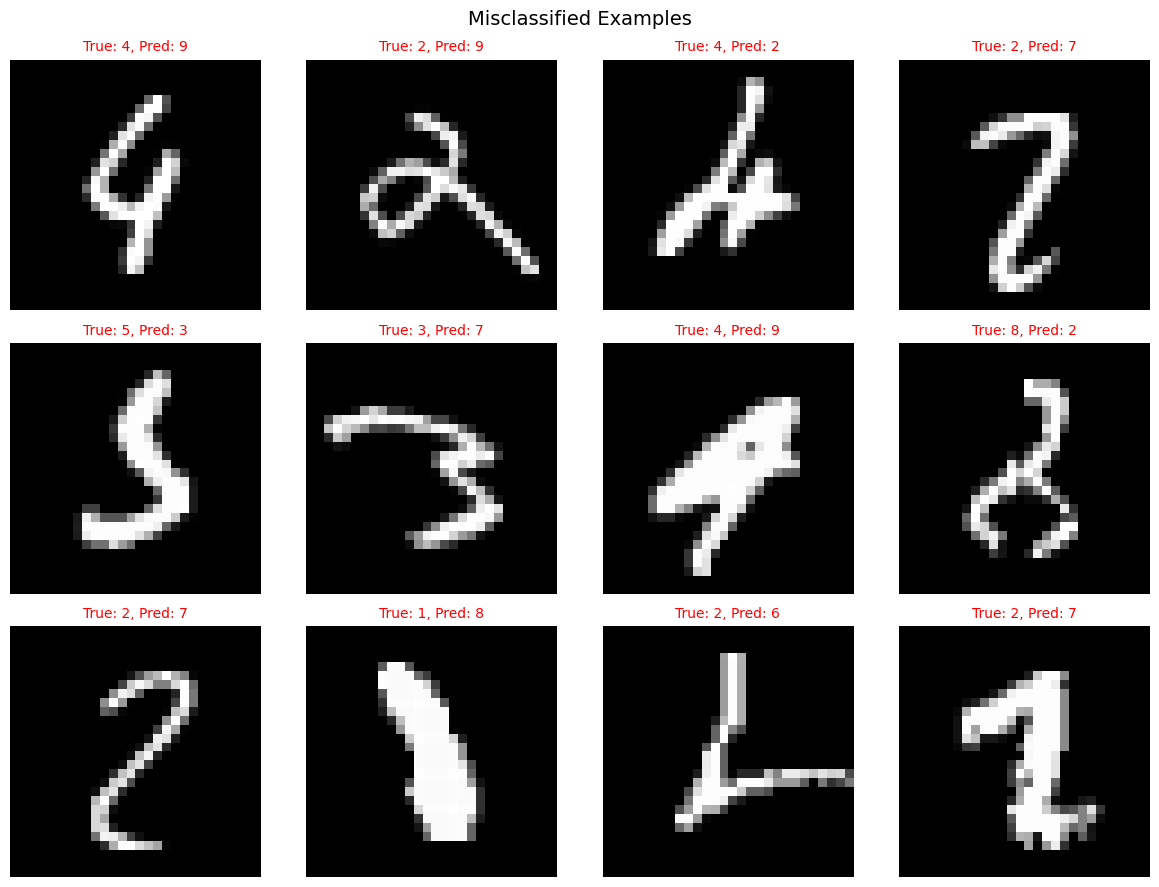

In [17]:
# Find misclassified examples
misclassified_idx = np.where(y_pred != y_true)[0]
print(f"Total misclassified: {len(misclassified_idx)} out of {len(y_true)} ({len(misclassified_idx)/len(y_true)*100:.2f}%)")

# Display first 12 misclassified examples
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
axes = axes.ravel()

for idx, mis_idx in enumerate(misclassified_idx[:12]):
    # Get original image (before flattening)
    original_image = test_images[mis_idx].reshape(28, 28)
    
    axes[idx].imshow(original_image, cmap='gray')
    axes[idx].set_title(f'True: {y_true[mis_idx]}, Pred: {y_pred[mis_idx]}', fontsize=10 , color='red')
    axes[idx].axis('off')

plt.suptitle('Misclassified Examples', fontsize=14)
plt.tight_layout()
plt.show()

Total correct: 9805 out of 10000 (98.05%)


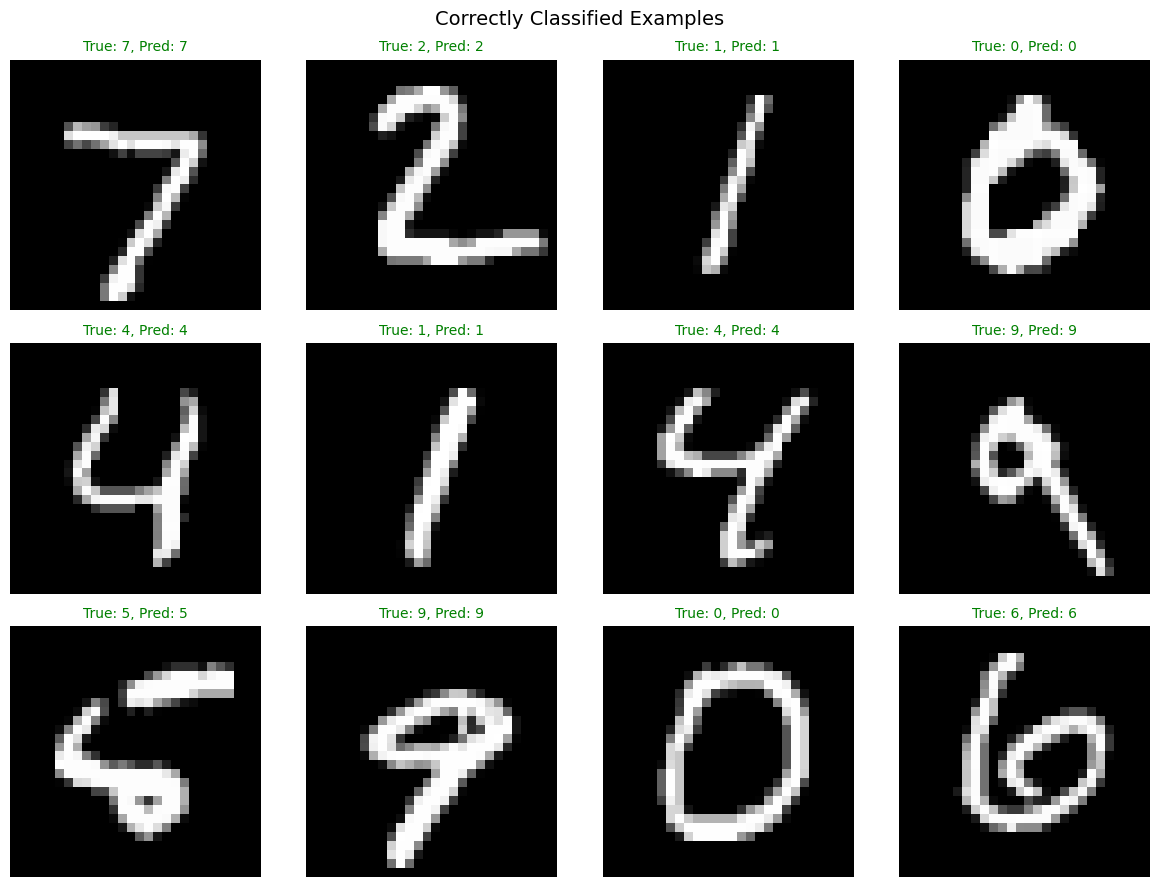

In [16]:
# Find correctly classified examples
correct_idx = np.where(y_pred == y_true)[0]
print(f"Total correct: {len(correct_idx)} out of {len(y_true)} ({len(correct_idx)/len(y_true)*100:.2f}%)")

# Display first 12 correct examples
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
axes = axes.ravel()

for idx, corr_idx in enumerate(correct_idx[:12]):
    original_image = test_images[corr_idx].reshape(28, 28)
    
    axes[idx].imshow(original_image, cmap='gray')
    axes[idx].set_title(f'True: {y_true[corr_idx]}, Pred: {y_pred[corr_idx]}', fontsize=10, color='green')
    axes[idx].axis('off')

plt.suptitle('Correctly Classified Examples', fontsize=14)
plt.tight_layout()
plt.show()

Per-Class Accuracy:
------------------------------
Digit 0: 98.57%
Digit 1: 99.21%
Digit 2: 97.19%
Digit 3: 98.51%
Digit 4: 96.44%
Digit 5: 97.20%
Digit 6: 98.64%
Digit 7: 98.64%
Digit 8: 98.15%
Digit 9: 97.72%


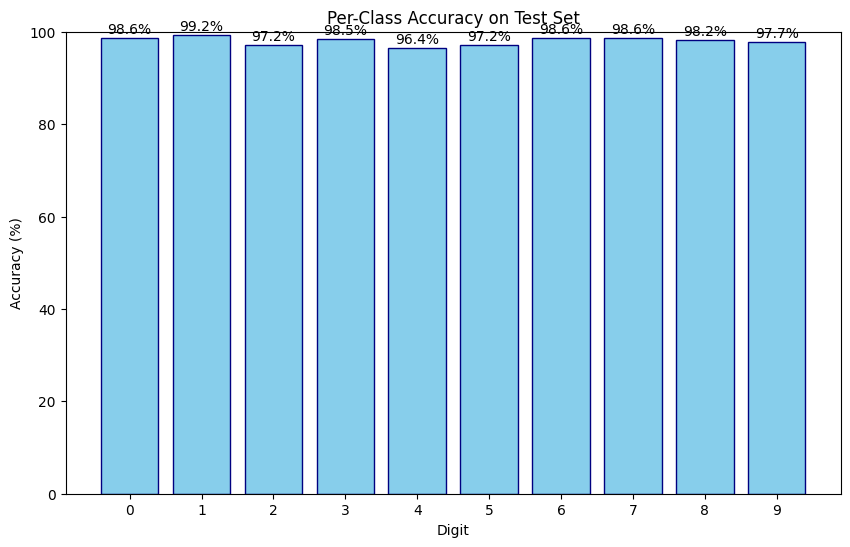

In [18]:
# Calculate per-class accuracy

class_correct = np.zeros(10)
class_total = np.zeros(10)

for i in range(len(y_true)):
    label = y_true[i]
    class_total[label] += 1
    if y_pred[i] == label:
        class_correct[label] += 1

class_accuracy = 100 * class_correct / class_total

# Display per-class accuracy
print("Per-Class Accuracy:")
print("-" * 30)
for digit in range(10):
    print(f"Digit {digit}: {class_accuracy[digit]:.2f}%")

# Plot
plt.figure(figsize=(10, 6))
plt.bar(range(10), class_accuracy, color='skyblue', edgecolor='navy')
plt.xlabel('Digit')
plt.ylabel('Accuracy (%)')
plt.title('Per-Class Accuracy on Test Set')
plt.ylim(0, 100)
plt.xticks(range(10))
for i, acc in enumerate(class_accuracy):
    plt.text(i, acc + 1, f'{acc:.1f}%', ha='center', fontsize=10)
plt.show()

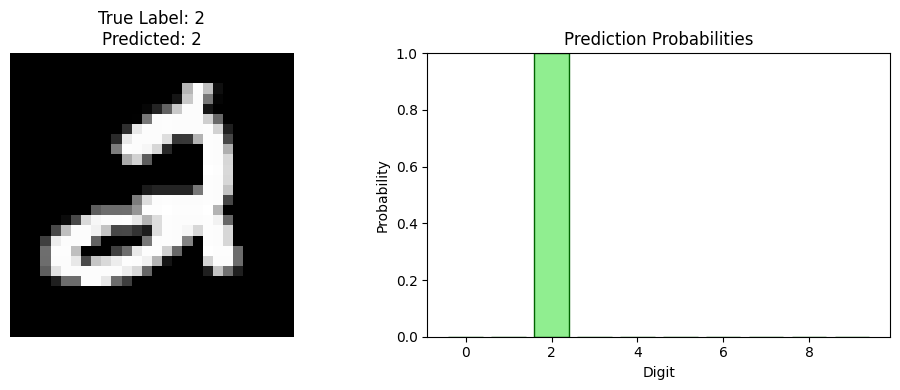

In [118]:
# Pick a random test image and show prediction
random_idx = np.random.randint(0, len(test_images))
sample_image = test_images[random_idx].reshape(28, 28)
sample_tensor = torch.FloatTensor(test_images[random_idx:random_idx+1]).to(device)

with torch.no_grad():
    output = model(sample_tensor)
    probabilities = torch.nn.functional.softmax(output, dim=1)
    predicted = torch.argmax(probabilities, dim=1).item()

# Display
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.imshow(sample_image, cmap='gray')
ax1.set_title(f'True Label: {test_labels[random_idx]}\nPredicted: {predicted}', fontsize=12)
ax1.axis('off')

# Show probabilities
probabilities_np = probabilities.cpu().numpy()[0]
ax2.bar(range(10), probabilities_np, color='lightgreen', edgecolor='darkgreen')
ax2.set_xlabel('Digit')
ax2.set_ylabel('Probability')
ax2.set_title('Prediction Probabilities')
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()